Saving Screenshot 2025-11-07 202535.png to Screenshot 2025-11-07 202535.png


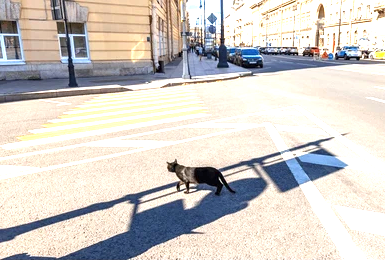

In [5]:
!pip install ultralytics
import cv2
import ultralytics
from google.colab.patches import cv2_imshow
from google.colab import files
import numpy as np
from IPython.display import Image

uploaded = files.upload()

# Assuming only one file is uploaded, get the filename and content
for filename, content in uploaded.items():
    # Convert bytes to numpy array
    np_arr = np.frombuffer(content, np.uint8)
    # Decode the image
    img_love = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)
    break # Process only the first uploaded file

if img_love is not None:

    cv2_imshow(img_love)
else:
    print("Error: Could not decode the image.")

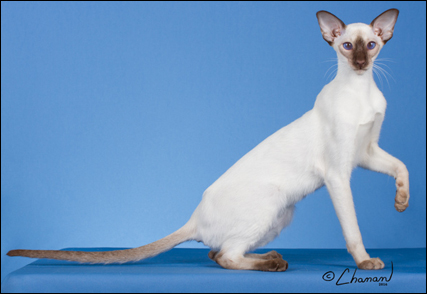

In [6]:
import cv2
import ultralytics
from google.colab.patches import cv2_imshow
import requests
from PIL import Image
from io import BytesIO
import numpy as np

# Use a publicly accessible image URL
image_url = 'https://nationalsiamese.com/images/AbChatDivaSK20_137.jpg'

try:
    response = requests.get(image_url)
    response.raise_for_status()  # Raise an exception for bad status codes

    img = Image.open(BytesIO(response.content))
    # Convert PIL image to OpenCV format (BGR)
    img_cat = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

    # You can uncomment this line if you need the RGB version
    # img_cat_rgb = cv2.cvtColor(img_cat, cv2.COLOR_BGR2RGB)

    cv2_imshow(img_cat)

except requests.exceptions.RequestException as e:
    print(f"Error fetching image from URL: {e}")
except Exception as e:
    print(f"An error occurred: {e}")



0: 448x640 1 dog, 2300.3ms
Speed: 5.7ms preprocess, 2300.3ms inference, 2.2ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 11 cars, 1 dog, 2237.2ms
Speed: 5.8ms preprocess, 2237.2ms inference, 4.6ms postprocess per image at shape (1, 3, 448, 640)


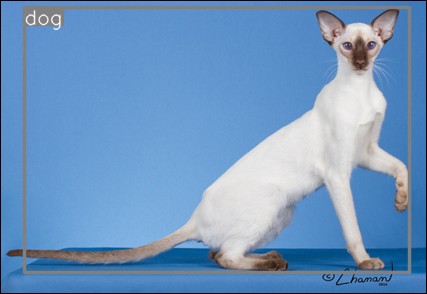

In [7]:
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator
model = YOLO('yolov8m.pt')
results1 = model.predict(img_cat)
for r in results1:
  annotator = Annotator(img_cat)
  boxes = r.boxes
  for box in boxes:
    b = box.xyxy[0]  # get box coordinates in (top, left, bottom, right) format
    c = box.cls
    annotator.box_label(b, model.names[int(c)])
img_catscan = annotator.result()
results2 = model.predict(img_love)
for r in results2:
  annotator2 = Annotator(img_love)

cv2_imshow(img_catscan)



0: 448x640 1 dog, 1079.8ms
Speed: 3.9ms preprocess, 1079.8ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 11 cars, 1 dog, 1025.8ms
Speed: 3.8ms preprocess, 1025.8ms inference, 3.0ms postprocess per image at shape (1, 3, 448, 640)


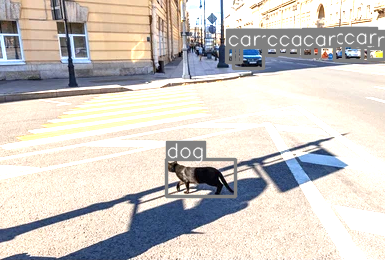

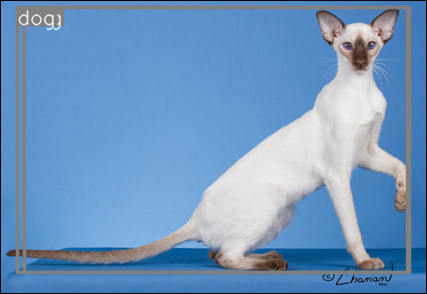

In [8]:
from ultralytics import YOLO
from ultralytics.utils.plotting import Annotator
model = YOLO('yolov8m.pt')
results1 = model.predict(img_cat)
for r in results1:
  annotator = Annotator(img_cat)
  boxes = r.boxes
  for box in boxes:
    b = box.xyxy[0]  # get box coordinates in (top, left, bottom, right) format
    c = box.cls
    annotator.box_label(b, model.names[int(c)])
img_catscan = annotator.result()
results2 = model.predict(img_love)
for r2 in results2:
  annotator2 = Annotator(img_love)
  boxes2 = r2.boxes
  for box in boxes2:
    b2 = box.xyxy[0]
    c2 = box.cls
    annotator2.box_label(b2, model.names[int(c2)])
img_catscan2 = annotator2.result()
cv2_imshow(img_catscan2)
cv2_imshow(img_catscan)

In [9]:
#next step? do it with a video of cars, examining a frame every 10 seconds to see if there is an car/person/truck/bus/bicycle in the frame
#so time to put a video in
!pip install yt-dlp
import yt_dlp
import os

#fine, I'll try using claude.
def download_youtube_video(url, output_path="youtube_video.mp4"):
    """
    Download a YouTube video.

    Args:
        url: YouTube video URL
        output_path: Path to save the downloaded video

    Returns:
        Path to the downloaded video file
    """
    print(f"Downloading video from: {url}")

    ydl_opts = {
        'format': 'best[ext=mp4]',  # Download best quality mp4
        'outtmpl': output_path,
        'quiet': False,
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])

    print(f"Video downloaded to: {output_path}")
    return output_path
def extract_frames_and_detect_cars(video_path, interval_seconds=10, output_dir="frames"):
    """
    Extract frames from video at specified intervals and detect cars using YOLO.

    Args:
        video_path: Path to the input video file
        interval_seconds: Time interval between frame extractions (default: 10 seconds)
        output_dir: Directory to save extracted frames (optional)

    Returns:
        List of tuples: [(timestamp, has_car, frame_path), ...]
    """
    # Load YOLO model (YOLOv8n is lightweight and fast)
    model = YOLO('yolov8n.pt')

    # Open video file
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Error opening video file: {video_path}")

    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps

    print(f"Video FPS: {fps}")
    print(f"Total frames: {total_frames}")
    print(f"Duration: {duration:.2f} seconds")

    # Calculate frame interval
    frame_interval = int(fps * interval_seconds)

    # Create output directory if saving frames
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    results = []
    frame_count = 0

    while True:
        # Set frame position
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_count)
        ret, frame = cap.read()

        if not ret:
            break

        # Calculate timestamp
        timestamp = frame_count / fps

        # Run YOLO detection
        detections = model(frame, verbose=False)

        # Check if any detected object is a car (class 2 in COCO dataset)
        # COCO classes: 2=car, 3=motorcycle, 5=bus, 7=truck
        has_car = False
        for detection in detections:
            for box in detection.boxes:
                class_id = int(box.cls[0])
                # Check for vehicles (car, motorcycle, bus, truck)
                if class_id in [2, 3, 5, 7]:
                    has_car = True
                    break
            if has_car:
                break

        # Save frame if output directory specified
        frame_path = None
        if output_dir:
            frame_path = os.path.join(output_dir, f"frame_{timestamp:.1f}s.jpg")
            cv2.imwrite(frame_path, frame)

        results.append((timestamp, has_car, frame_path))
        print(f"Time: {timestamp:.1f}s - Car detected: {has_car}")

        # Move to next interval
        frame_count += frame_interval

        if frame_count >= total_frames:
            break

    cap.release()
    return results


def simple_car_check(video_path, interval_seconds=10):
    """
    Simplified version that just returns True/False for each frame.

    Returns:
        List of booleans indicating car presence at each interval
    """
    results = extract_frames_and_detect_cars(video_path, interval_seconds, output_dir=None)
    return [has_car for _, has_car, _ in results]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 53.2 MB/s eta 0:00:00
